Extract averaged percent change in biological group biomass for each time period and contaminant release scenario location.

In [1]:
import os
import xarray as xr
import numpy as np
import pandas as pd
import itertools
import seaborn as sns
from pathlib import Path
import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import ssam_groups as groups
from mpl_toolkits.axes_grid1 import make_axes_locatable

### Define scenario and control files

In [2]:
control_root = Path('/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/Control/')
control_paths = sorted([p for p in control_root.glob('highres-control-3y-*/outputSalishSea.nc')])
for path in control_paths:
    print(path.parent.stem)

highres-control-3y-2019-2022
highres-control-3y-2029-2032
highres-control-3y-2039-2042


In [4]:
control_datasets = [xr.open_dataset(ctr,decode_cf=True) for ctr in control_paths]

In [17]:
scenario_root = Path('/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI1/Smother-test/')
scenario_paths = sorted([p for p in scenario_root.glob('6a_2019-07-16_2*/outputSalishSea.nc')])
for path in scenario_paths:
    print(path.parent.stem)

6a_2019-07-16_2019-2022
6a_2019-07-16_2039-2042


In [18]:
scenario_datasets = [xr.open_dataset(scen,decode_cf=True) for scen in scenario_paths]

In [24]:
def average_boxplot_data_pelagic(bio_group, location=groups.salish_sea):
    all_results = []
    data_labels = ['spill year', '20 years later']

    for scenario, path in zip(scenario_datasets[0:1], scenario_paths[0:1]):
        control = control_datasets[0]
        nm = str(path.parent.stem).split(sep='_')
        year = str(nm[1])
        scenario_name = 'EB-'+groups.conditions_with_letters[str(groups.simulations[groups.conditions[nm[1]]])]

        group_ratio = 0
        for species in bio_group: 
            p_ratio = 0
            p_oiled = np.ma.filled(scenario.variables[bio_group[species] + '_N'][:, location, 0:6], np.nan)
            p_control = np.ma.filled(control.variables[bio_group[species] + '_N'][:, location, 0:6], np.nan)
        
            p_oiled = p_oiled.sum(axis=(1, 2)).mean()+groups.base_biomass[bio_group[species]]
            p_control = p_control.sum(axis=(1, 2)).mean()+groups.base_biomass[bio_group[species]]
            p_ratio = (p_oiled / p_control - 1) * 100
            
            all_results.append({
            'bio_group': species,
            'time_label': 'spill year',
            'scenario': scenario_name,
            'percent_change': p_ratio,
            'sensitivity': groups.sensitivity[bio_group[species]],
            'sensitivity_negative': -groups.sensitivity[bio_group[species]],
            })

    for scenario, path in zip(scenario_datasets[1:len(scenario_datasets)+1], scenario_paths[1:len(scenario_datasets)+1]):
        control = control_datasets[2]
        nm = str(path.parent.stem).split(sep='_')
        year = str(nm[1])
        scenario_name = 'EB-'+groups.conditions_with_letters[str(groups.simulations[groups.conditions[nm[1]]])]

        group_ratio = 0
        for species in bio_group: 
            p_ratio = 0
            p_oiled = np.ma.filled(scenario.variables[bio_group[species] + '_N'][:, location, 0:6], np.nan)
            p_control = np.ma.filled(control.variables[bio_group[species] + '_N'][:, location, 0:6], np.nan)
        
            p_oiled = p_oiled.sum(axis=(1, 2)).mean()+groups.base_biomass[bio_group[species]]
            p_control = p_control.sum(axis=(1, 2)).mean()+groups.base_biomass[bio_group[species]]
            p_ratio = (p_oiled / p_control - 1) * 100
            
            all_results.append({
            'bio_group': species,
            'time_label': '20 years later',
            'scenario': scenario_name,
            'percent_change': p_ratio,
            'sensitivity': groups.sensitivity[bio_group[species]],
            'sensitivity_negative': -groups.sensitivity[bio_group[species]],
            })

    df = pd.DataFrame(all_results)
    df.to_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI1/Smother-test/averaged-data-"+bio_group[species]+".csv")

In [25]:
def average_boxplot_data_vertebrates(bio_group, location=groups.salish_sea):
    all_results = []
    data_labels = ['spill year', '20 years later']

    for scenario, path in zip(scenario_datasets[0:1], scenario_paths[0:1]):
        control = control_datasets[0]
        nm = str(path.parent.stem).split(sep='_')
        year = str(nm[1])
        scenario_name = 'EB-'+groups.conditions_with_letters[str(groups.simulations[groups.conditions[nm[1]]])]
            
        average_ratio = 0
        for species in bio_group:

            species_ratio = 0

            numCohorts = groups.cohorts[bio_group[species]]
            for cohort in range (1, numCohorts+1):
                new_species = bio_group[species] + str(cohort)
            
                o_numbers_tbl = np.ma.filled(scenario.variables[new_species + '_Nums'][:, location, 0:6], np.nan)
                o_structuralN_tbl = np.ma.filled(scenario.variables[new_species +'_StructN'][:, location, 0:6], np.nan)
                o_reservedN_tbl = np.ma.filled(scenario.variables[new_species +'_ResN'][:, location, 0:6], np.nan)

                c_numbers_tbl = np.ma.filled(control.variables[new_species + '_Nums'][:, location, 0:6], np.nan)
                c_structuralN_tbl = np.ma.filled(control.variables[new_species +'_StructN'][:, location, 0:6], np.nan)
                c_reservedN_tbl = np.ma.filled(control.variables[new_species +'_ResN'][:, location, 0:6], np.nan)

                o_weightatage_tbl = (o_structuralN_tbl + o_reservedN_tbl) * o_numbers_tbl 
                o_weightatage = o_weightatage_tbl.sum(axis=(1,2)).mean()

                c_weightatage_tbl = (c_structuralN_tbl + c_reservedN_tbl) * c_numbers_tbl 
                c_weightatage = c_weightatage_tbl.sum(axis=(1,2)).mean()

                cohort_ratio = (o_weightatage / c_weightatage - 1) * 100
                #print(scenario_name, species, cohort, cohort_ratio)
                species_ratio = species_ratio + cohort_ratio

            final_species_ratio = species_ratio/numCohorts
        
            all_results.append({
            'bio_group': species,
            'time_label': 'spill year',
            'scenario': scenario_name,
            'percent_change': final_species_ratio,
            'sensitivity': groups.sensitivity[bio_group[species]],
            'sensitivity_negative': -groups.sensitivity[bio_group[species]],
            })
    
    for scenario, path in zip(scenario_datasets[1:len(scenario_datasets)+1], scenario_paths[1:len(scenario_datasets)+1]):
        control = control_datasets[2]
        nm = str(path.parent.stem).split(sep='_')
        year = str(nm[1])
        scenario_name = 'EB-'+groups.conditions_with_letters[str(groups.simulations[groups.conditions[nm[1]]])]
            
        average_ratio = 0
        for species in bio_group:

            species_ratio = 0

            numCohorts = groups.cohorts[bio_group[species]]
            for cohort in range (1, numCohorts+1):
                new_species = bio_group[species] + str(cohort)
            
                o_numbers_tbl = np.ma.filled(scenario.variables[new_species + '_Nums'][:, location, 0:6], np.nan)
                o_structuralN_tbl = np.ma.filled(scenario.variables[new_species +'_StructN'][:, location, 0:6], np.nan)
                o_reservedN_tbl = np.ma.filled(scenario.variables[new_species +'_ResN'][:, location, 0:6], np.nan)

                c_numbers_tbl = np.ma.filled(control.variables[new_species + '_Nums'][:, location, 0:6], np.nan)
                c_structuralN_tbl = np.ma.filled(control.variables[new_species +'_StructN'][:, location, 0:6], np.nan)
                c_reservedN_tbl = np.ma.filled(control.variables[new_species +'_ResN'][:, location, 0:6], np.nan)

                o_weightatage_tbl = (o_structuralN_tbl + o_reservedN_tbl) * o_numbers_tbl 
                o_weightatage = o_weightatage_tbl.sum(axis=(1,2)).mean()

                c_weightatage_tbl = (c_structuralN_tbl + c_reservedN_tbl) * c_numbers_tbl 
                c_weightatage = c_weightatage_tbl.sum(axis=(1,2)).mean()

                cohort_ratio = (o_weightatage / c_weightatage - 1) * 100
                #print(scenario_name, species, cohort, cohort_ratio)
                species_ratio = species_ratio + cohort_ratio

            final_species_ratio = species_ratio/numCohorts
            
            all_results.append({
            'bio_group': species,
            'time_label': '20 years later',
            'scenario': scenario_name,
            'percent_change': final_species_ratio,
            'sensitivity': groups.sensitivity[bio_group[species]],
            'sensitivity_negative': -groups.sensitivity[bio_group[species]],
            })

    df = pd.DataFrame(all_results)
    df.to_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI1/Smother-test/averaged-data-"+bio_group[species]+".csv")

In [26]:
def average_boxplot_data_benthic(bio_group, location=groups.salish_sea):
    all_results = []
    data_labels = ['spill year', '20 years later']

    for scenario, path in zip(scenario_datasets[0:1], scenario_paths[0:1]):
        control = control_datasets[0]
        nm = str(path.parent.stem).split(sep='_')
        year = str(nm[1])
        scenario_name = 'EB-'+groups.conditions_with_letters[str(groups.simulations[groups.conditions[nm[1]]])]

        for species in bio_group: 
            p_oiled = np.ma.filled(scenario.variables[bio_group[species] + '_N'][:, location], np.nan)
            p_control = np.ma.filled(control.variables[bio_group[species] + '_N'][:, location], np.nan)
        
            p_oiled = p_oiled.sum(axis=1).mean()+groups.base_biomass[bio_group[species]]
            p_control = p_control.sum(axis=1).mean()+groups.base_biomass[bio_group[species]]
            p_ratio = (p_oiled / p_control - 1) * 100

            all_results.append({
            'bio_group': species,
            'time_label': 'spill year',
            'scenario': scenario_name,
            'percent_change': p_ratio,
            'sensitivity': groups.sensitivity[bio_group[species]],
            'sensitivity_negative': -groups.sensitivity[bio_group[species]],
            })
    
    for scenario, path in zip(scenario_datasets[1:len(scenario_datasets)+1], scenario_paths[1:len(scenario_datasets)+1]):
        control = control_datasets[2]
        nm = str(path.parent.stem).split(sep='_')
        year = str(nm[1])
        scenario_name = 'EB-'+groups.conditions_with_letters[str(groups.simulations[groups.conditions[nm[1]]])]

        for species in bio_group: 
            p_oiled = np.ma.filled(scenario.variables[bio_group[species] + '_N'][:, location], np.nan)
            p_control = np.ma.filled(control.variables[bio_group[species] + '_N'][:, location], np.nan)
        
            p_oiled = p_oiled.sum(axis=1).mean()+groups.base_biomass[bio_group[species]]
            p_control = p_control.sum(axis=1).mean()+groups.base_biomass[bio_group[species]]
            p_ratio = (p_oiled / p_control - 1) * 100
            
            all_results.append({
            'bio_group': species,
            'time_label': '20 years later',
            'scenario': scenario_name,
            'percent_change': p_ratio,
            'sensitivity': groups.sensitivity[bio_group[species]],
            'sensitivity_negative': -groups.sensitivity[bio_group[species]],
            })

    df = pd.DataFrame(all_results)
    df.to_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI1/Smother-test/averaged-data-"+bio_group[species]+".csv")

In [27]:
average_boxplot_data_pelagic(groups.plankton)

In [28]:
average_boxplot_data_benthic(groups.benthic_invertebrates)

In [29]:
average_boxplot_data_benthic(groups.macroalgae)

In [30]:
average_boxplot_data_vertebrates(groups.salmon)

In [31]:
average_boxplot_data_vertebrates(groups.named_fish)

In [32]:
average_boxplot_data_vertebrates(groups.other_fish)

In [33]:
average_boxplot_data_vertebrates(groups.mammals)

In [34]:
average_boxplot_data_vertebrates(groups.sharks)

In [35]:
average_boxplot_data_vertebrates(groups.birds)

In [36]:
average_boxplot_data_pelagic(groups.pelagic_invertebrates)

In [37]:
results_root = Path('/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI1/Smother-test/')
results_paths = sorted([p for p in results_root.glob('averaged-data-*.csv')])
averaged_data = []
for file in results_paths:
    df1 = pd.read_csv(file)
    averaged_data.append(df1[['bio_group', 'time_label','scenario', 'percent_change','sensitivity','sensitivity_negative']])

averaged_data_df = pd.concat(averaged_data, ignore_index=True)
averaged_data_df.to_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI1/Smother-test/averaged_data.csv")

In [4]:
smother = pd.read_csv("/ocean/rlovindeer/MOAD/Lovindeeretal-MPRI1paper/smother_data.csv")
smother_control = pd.read_csv("/ocean/rlovindeer/MOAD/Lovindeeretal-MPRI1paper/averaged_data.csv")

In [38]:
code_names = {'EB'}

In [19]:
# Extract EB-FlTs cenario data from all the data

df1 = []
for time in time_labels:
    df = smother_control[(smother_control['time_label'] == time) & (smother_control['scenario'] == 'EB-FlTs')]
    df1.append(df[['bio_group', 'time_label','scenario', 'percent_change','sensitivity','sensitivity_negative']])    
smother_data_df = pd.concat(df1, ignore_index=True)
smother_data_df.to_csv("/ocean/rlovindeer/MOAD/Lovindeeretal-MPRI1paper/smother_compare_data.csv")

In [21]:
# Pool EB-FlTs and EB-FLTs-smother into one file
results_root = Path('/ocean/rlovindeer/MOAD/Lovindeeretal-MPRI1paper/')
results_paths = sorted([p for p in results_root.glob('smother*.csv')])
smother_comparison_data = []
for file in results_paths:
    df2 = pd.read_csv(file)
    smother_comparison_data.append(df2[['bio_group', 'time_label','scenario', 'percent_change','sensitivity','sensitivity_negative']])

smother_comparison_data_df = pd.concat(smother_comparison_data, ignore_index=True)
smother_comparison_data_df.to_csv("/ocean/rlovindeer/MOAD/Lovindeeretal-MPRI1paper/comparison_smother_data.csv")

## Start here

In [2]:
hex_colour = '#2F61A4'

In [3]:
df = pd.read_csv("/ocean/rlovindeer/MOAD/Lovindeeretal-MPRI1paper/comparison_smother_data.csv")

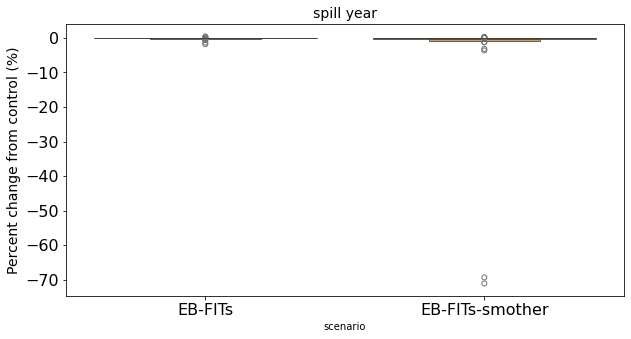

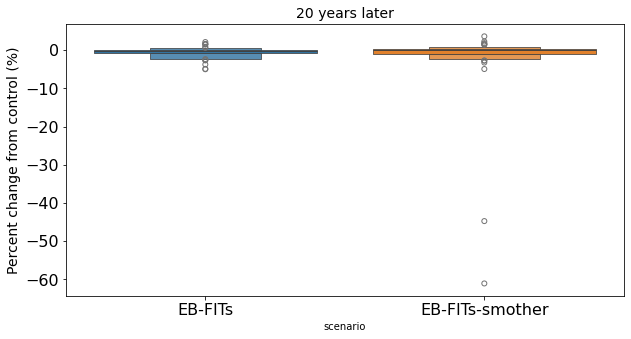

In [5]:
# Compare EB smother and control scenarios
time_labels = ['spill year', '20 years later']
for time in time_labels:
    df_pivot = df.loc[df['time_label'] == time].pivot_table(
        index='bio_group', 
        columns='scenario', 
        values='percent_change', 
    )
    plt.figure(figsize=(10, 5))                  
    ax = sns.boxenplot(df_pivot)
    plt.ylabel('Percent change from control (%)', fontsize = 14)
    #plt.ylim(-20, 20)
    #plt.xticks(rotation=45)
    ax.tick_params(labelsize=16)
    plt.title(time,fontsize = 14)
    plt.savefig('Figures/smother-'+time+'.png', dpi=300)
plt.savefig('Figures/smother-'+time+'.png',dpi=300)

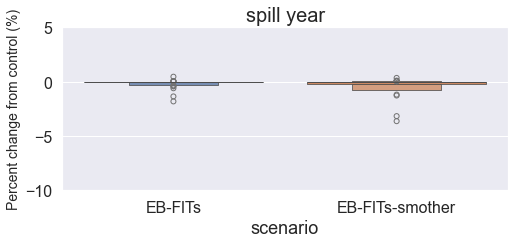

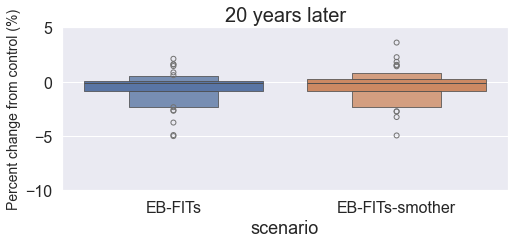

In [65]:
# Plot EB smother and control scenarios - zoomed in (cut off the birds)
time_labels = ['spill year', '20 years later']
sns.set(font_scale = 1.5)
for time in time_labels:
    df_pivot = df.loc[df['time_label'] == time].pivot_table(
        index='bio_group', 
        columns='scenario', 
        values='percent_change', 
    )
    plt.figure(figsize=(8, 3))                  
    ax = sns.boxenplot(df_pivot)
    plt.ylabel('Percent change from control (%)', fontsize = 14)
    plt.ylim(-10, 5)
    #plt.xticks(rotation=45)
    plt.title(time,fontsize = 20)
    plt.savefig('Figures/smother-zoomed'+time+'.png', dpi=300)
plt.savefig('Figures/smother-zoomed'+time+'.png',dpi=300)

## Box plots

In [6]:
time_labels = df['time_label'].unique()
scenarios = df['scenario'].unique()
bio_groups = df['bio_group'].unique()

hatches = ['oo', '///', 'xx', '++']
alphas = [0.5, 0.75, 0.3, 1]
colors = plt.cm.tab10.colors

In [7]:
## Plotting function
def plot_boxplot(bio_groups, plot_name, x_lim=None, n_col=1, bbox_x=0.98, bbox_y=0.92):
    
    df_plot = []

    n_rows = len(bio_groups)
    n_cols = len(time_labels)
    
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, n_rows), sharey=True)

    if n_cols == 1:
        axes = [axes]  
    
    bar_width = 0.8 / len(scenarios)  
    y_pos = np.arange(len(bio_groups))

    for i, time in enumerate(time_labels):
        ax = axes[i]
        for j, scenario in enumerate(scenarios):
            df_plot = df[(df['time_label'] == time) & (df['scenario'] == scenario)]
            df_plot = df_plot.set_index('bio_group').reindex(bio_groups)  
            offset = (j - len(scenarios)/1.5) * bar_width + bar_width/1.5

            ax.barh(y_pos + offset, df_plot['percent_change'], height=bar_width, label=scenario, facecolor=hex_colour, alpha=alphas[j], edgecolor='black', hatch=hatches[j])
        ax.xaxis.grid(True)
        xlabels = ax.get_xticklabels()
        plt.setp(xlabels, fontsize=16)
    
        ax.set_title(time, fontsize=20)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(bio_groups, fontsize=20) 
        ax.set_xlim(x_lim)
        ax.set_xlabel("Percent Change", fontsize=20)

    fig.legend(scenarios, loc='upper center', ncol=n_col, fontsize=18, bbox_to_anchor=(bbox_x, bbox_y))#ncol=len(these_scenarios)
    fig.savefig('Figures/'+plot_name+'-boxplot.png', dpi=300, bbox_inches='tight')
    plt.show()

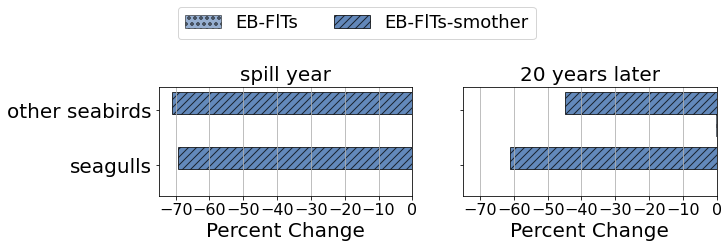

In [58]:
plot_boxplot(groups.birds, 'smother-birds',x_lim=[-75,0],n_col=2,bbox_x=0.4,bbox_y=1.5)

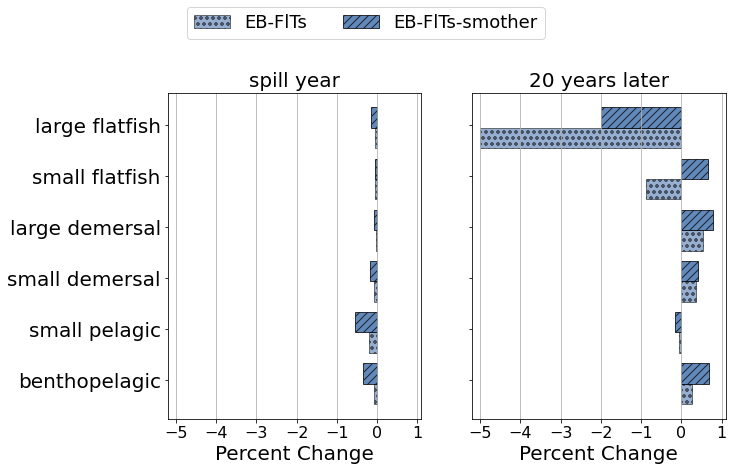

In [17]:
plot_boxplot(groups.other_fish, 'smother-fish',x_lim=[-5.2,1.1],n_col=2,bbox_x=0.4,bbox_y=1.1)

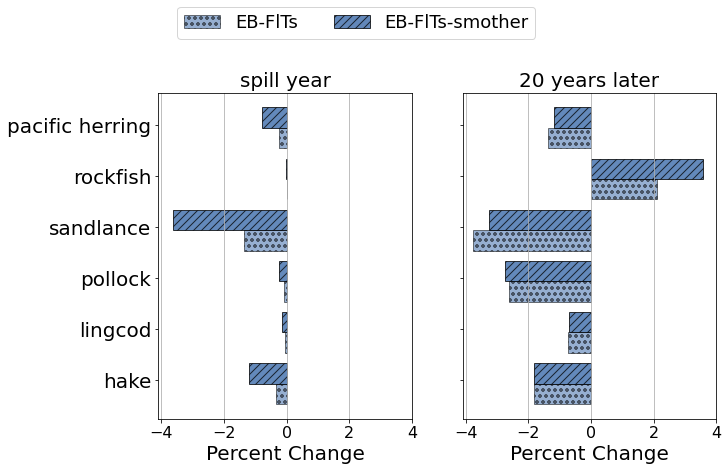

In [16]:
plot_boxplot(groups.named_fish, 'smother-herring',x_lim=[-4.1,4],n_col=2,bbox_x=0.4,bbox_y=1.1)

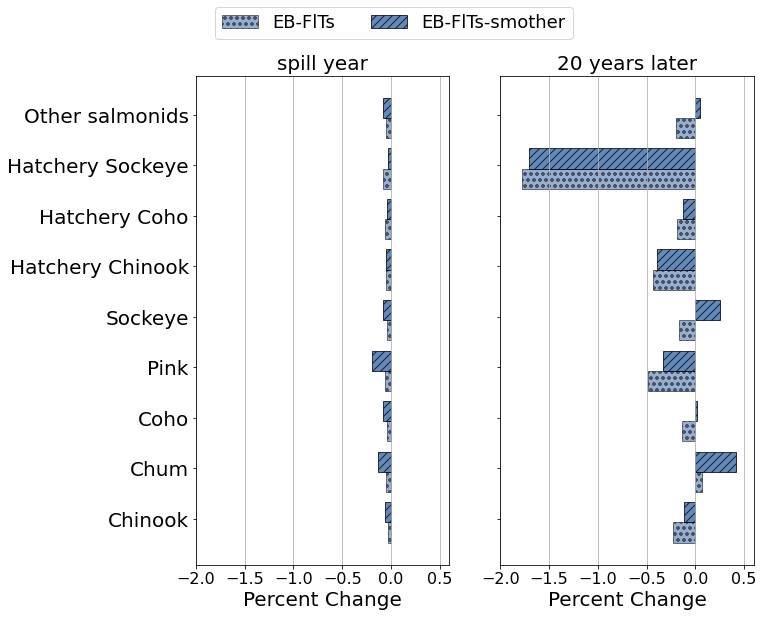

In [20]:
plot_boxplot(groups.salmon, 'smother-salmon',n_col=2,x_lim=[-2,0.6],bbox_x=0.4,bbox_y=1)

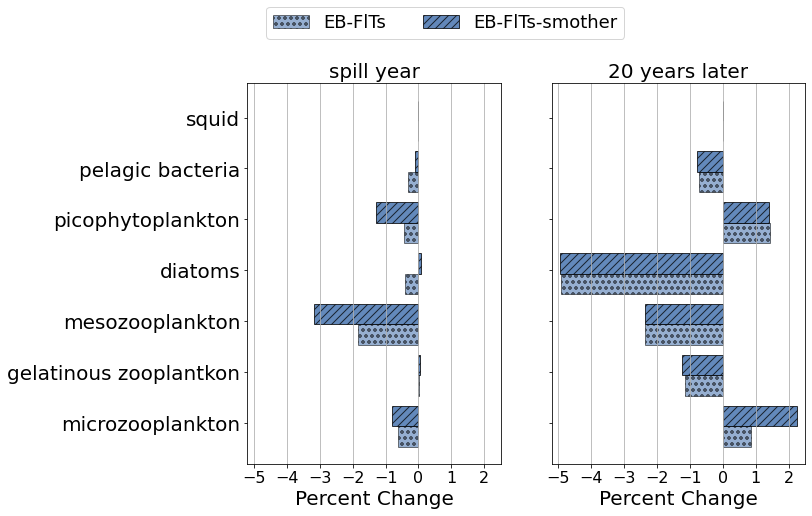

In [22]:
plot_boxplot(groups.planktonic, 'smother-plankton',x_lim=[-5.2,2.5],n_col=2,bbox_x=0.4,bbox_y=1.05)